# Analysis

In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Output folders
TABLE_DIR = Path("tables")
FIGURE_DIR = Path("figures")

TABLE_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

def export_table(df, name, decimals=6):
    """
    Export table as CSV and a rounded display version as Markdown.
    CSV preserves full precision; Markdown is README-friendly.
    """
    csv_path = TABLE_DIR / f"{name}.csv"
    md_path = TABLE_DIR / f"{name}.md"

    df.to_csv(csv_path, index=False)

    display_df = df.copy()
    num_cols = display_df.select_dtypes(include="number").columns
    display_df[num_cols] = display_df[num_cols].round(decimals)

    with open(md_path, "w") as f:
        f.write(display_df.to_markdown(index=False))

    print(f"Exported: {csv_path}")
    print(f"Exported: {md_path}")

def save_current_fig(name):
    """
    Save the current matplotlib figure as PNG and PDF.
    """
    fig = plt.gcf()
    fig.savefig(FIGURE_DIR / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{name}.pdf", bbox_inches="tight")
    print(f"Exported: figures/{name}.png")
    print(f"Exported: figures/{name}.pdf")

## Data Preparation

In [10]:
import yfinance as yf

spy_train = yf.download(
    'SPY', 
    start='2000-01-01',
    end='2019-12-31',
    auto_adjust=True, 
    progress=False
)

spy_test = yf.download(
    'SPY', 
    start='2020-01-01',
    end='2025-12-31',
    auto_adjust=True, 
    progress=False
)

logret = np.log(spy_train['Close']).diff().dropna() * 100
logret_test = np.log(spy_test['Close']).diff().dropna() * 100

## Model Selection

We first pick the best model out of the 2, 3, 4 and 5 state HMMs.

We select the number of regimes by BIC, subject to a minimum persistence constraint of > 5 days. Any model that doesn't meet the constraints is automatically degenerate and will be rejected.

In [12]:
from src import models
from src.utils.hmm_fitting import fit_best
from src.utils.info_criteria import bic, aic

hmm2 = fit_best(models.GHMM, data=logret, n_seeds=50, n_states=2)
hmm3 = fit_best(models.GHMM, data=logret, n_seeds=50, n_states=3)
hmm4 = fit_best(models.GHMM, data=logret, n_seeds=50, n_states=4)
hmm5 = fit_best(models.GHMM, data=logret, n_seeds=50, n_states=5)

all_hmms = [hmm2, hmm3, hmm4, hmm5]

ModuleNotFoundError: No module named 'src'

In [2]:
def get_transition_matrix(hmm):
    if hasattr(hmm, "model") and hasattr(hmm.model, "transmat_"):
        return np.asarray(hmm.model.transmat_)
    if hasattr(hmm, "transmat_"):
        return np.asarray(hmm.transmat_)
    if hasattr(hmm, "trans_mat"):
        return np.asarray(hmm.trans_mat)
    raise AttributeError("Could not find transition matrix attribute.")

hmm_selection_rows = []

for hmm in all_hmms:
    transmat = get_transition_matrix(hmm)
    durations = 1 / (1 - np.diag(transmat))

    hmm_selection_rows.append({
        "States": hmm.n_states,
        "AIC": aic(hmm.loglik, hmm.n_params),
        "BIC": bic(hmm.loglik, hmm.n_params, len(logret)),
        "Minimum Expected Duration": np.min(durations),
        "Maximum Expected Duration": np.max(durations),
        "Degenerate": np.min(durations) < 5
    })

hmm_selection_table = pd.DataFrame(hmm_selection_rows)

display(hmm_selection_table)
export_table(hmm_selection_table, "hmm_model_selection")

NameError: name 'all_hmms' is not defined

## Regime Validation

In [5]:
import src.utils.hmm_diagnostics as diag

diag.print_transition_matrix(hmm4)
print()
diag.print_exp_durations(hmm4)
print()
diag.print_state_stats(hmm4, logret)
print()
diag.print_params(hmm4)

4-State HMM Transition Matrix:
State 0: 0.950635 0.047095 0.000000 0.002271
State 1: 0.050685 0.938210 0.000000 0.011104
State 2: 0.000000 0.000000 0.953420 0.046580
State 3: 0.000000 0.019777 0.006096 0.974127

4-State HMM Expected Durations:
State 0 Expected Duration: 20.257121
State 1 Expected Duration: 16.183938
State 2 Expected Duration: 21.468466
State 3 Expected Duration: 38.650465

4-State HMM Sample Statistics:
State    Count        Mean    Variance
0         1815    0.110174    0.218338
1         1671    0.032102    0.827913
2          155   -0.271328   14.210203
3         1388   -0.068357    2.285474

4-State HMM Parameters:
State       Mean  Variance
0       0.123712  0.214221
1       0.020363  0.834958
2      -0.262879 12.460234
3      -0.075164  2.341940


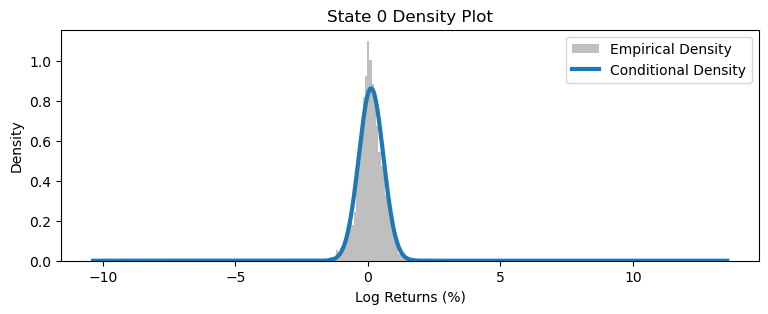

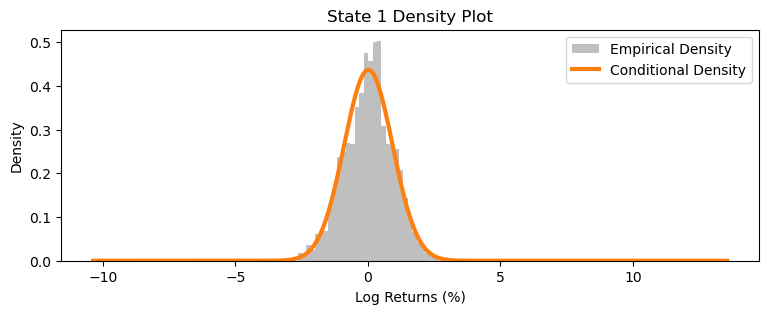

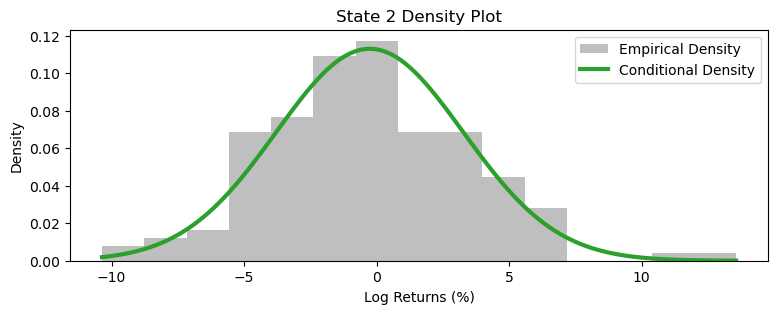

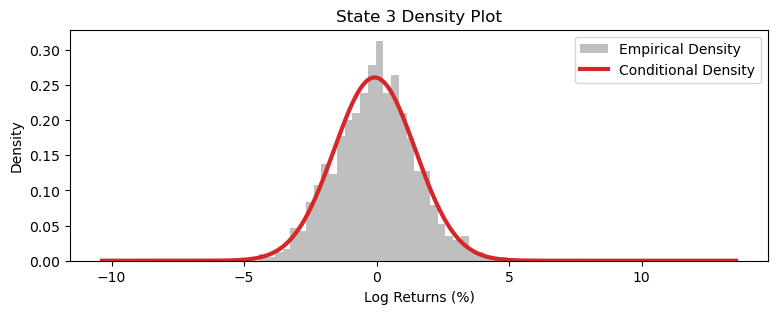

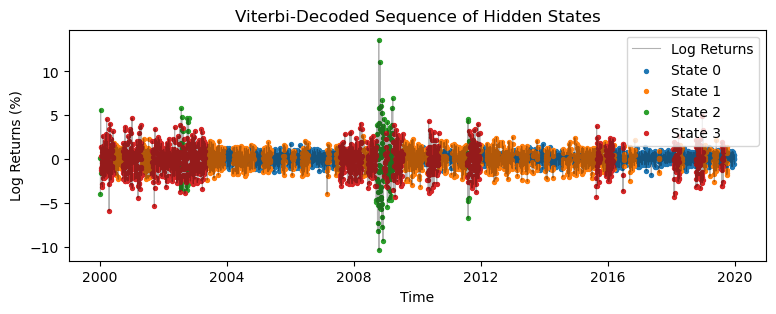

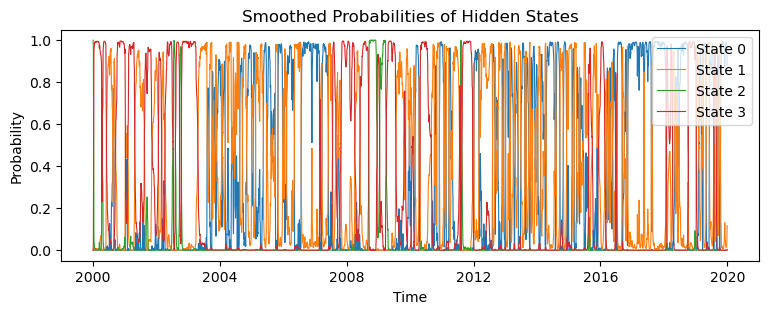

In [6]:
import src.plots.hmm_plots as plot

plot.plot_densities(hmm4, logret)
plot.plot_viterbi_seq(hmm4, logret)
plot.plot_probs(hmm4, logret)

## Benchmarking with Predictive Log Score

In [7]:
gaussian = models.Gaussian()
student_t = models.StudentT()
garch_g = models.GARCH(1, 1, distribution='normal')
garch_t = models.GARCH(1, 1, distribution='t')
benchmarks = [gaussian, student_t, garch_g, garch_t]
for model in benchmarks: 
    model.fit(logret)

all_models = {
    '4-state HMM' : hmm4,
    'Gaussian' : gaussian,
    'Student-t' : student_t, 
    'GARCH(1,1)' : garch_g, 
    't-GARCH(1,1)' : garch_t
}

print(f"{'Model':<12}{'AIC':>14}{'BIC':>14}{'Log-Score':>12}")
for name, model in all_models.items(): 
    print(f"{name:<12}" +
          f"{aic(model.loglik, model.n_params):14.6f}" +
          f"{bic(model.loglik, model.n_params, len(logret)):14.6f}", 
          f"{model.log_predictive_density(logret_test).mean():12.6f}"
    )

Model                  AIC           BIC   Log-Score
4-state HMM   13448.656401  13598.684859    -1.412108
Gaussian      16063.561782  16076.607735    -1.698295
Student-t     14663.975103  14683.544032    -1.522812
GARCH(1,1)    13671.568269  13691.137199    -1.446153
t-GARCH(1,1)  13459.769282  13485.861188    -1.424251


In [ ]:
from dieboldmariano import dm_test

gaussian = models.Gaussian()
student_t = models.StudentT()
garch_g = models.GARCH(1, 1, distribution='normal')
garch_t = models.GARCH(1, 1, distribution='t')

benchmarks = [gaussian, student_t, garch_g, garch_t]

for model in benchmarks: 
    model.fit(logret)

all_models = {
    '4-state HMM': hmm4,
    'Gaussian': gaussian,
    'Student-t': student_t, 
    'GARCH(1,1)': garch_g, 
    't-GARCH(1,1)': garch_t
}

# Store log predictive densities once
log_scores = {}

for name, model in all_models.items():
        log_scores[name] = model.log_predictive_density(logret_test)


print(f"{'Model':<16}{'AIC':>14}{'BIC':>14}{'Log-Score':>12}")

for name, model in all_models.items(): 
    print(
        f"{name:<16}"
        f"{aic(model.loglik, model.n_params):14.6f}"
        f"{bic(model.loglik, model.n_params, len(logret)):14.6f}"
        f"{log_scores[name].mean():12.6f}"
    )


print("\nDM tests against 4-state HMM using negative log predictive density")
print(f"{'Comparison':<28}{'DM Stat':>12}{'p-value':>12}{'Mean Diff':>14}")

hmm_loss = -np.asarray(log_scores['4-state HMM']).ravel()
actual = np.zeros(len(hmm_loss))

for name in all_models:
    if name == '4-state HMM':
        continue

    model_loss = -np.asarray(log_scores[name]).ravel()

    dm_stat, p_value = dm_test(
        actual,
        hmm_loss,
        model_loss,
        loss=lambda actual, pred: pred,
        h=1,
        one_sided=False,
        harvey_correction=True,
        variance_estimator="bartlett"
    )

    mean_diff = np.mean(hmm_loss - model_loss)

    print(
        f"{'HMM vs ' + name:<28}"
        f"{dm_stat:12.6f}"
        f"{p_value:12.6f}"
        f"{mean_diff:14.6f}"
    )

Model                      AIC           BIC   Log-Score
4-state HMM       13448.656401  13598.684859   -1.412108
Gaussian          16063.561782  16076.607735   -1.698295
Student-t         14663.975103  14683.544032   -1.522812
GARCH(1,1)        13671.568269  13691.137199   -1.446153
t-GARCH(1,1)      13459.769282  13485.861188   -1.424251

DM tests against 4-state HMM using negative log predictive density
Comparison                       DM Stat     p-value     Mean Diff
HMM vs Gaussian                -5.715542    0.000000     -0.286187
HMM vs Student-t               -8.376473    0.000000     -0.110703
HMM vs GARCH(1,1)              -3.162955    0.001593     -0.034045
HMM vs t-GARCH(1,1)            -2.280225    0.022734     -0.012142


Exploring other GARCH extensions: 

In [9]:
garch11_t = models.GARCH(1, 1, distribution='t')
garch12_t = models.GARCH(1, 2, distribution='t')
garch21_t = models.GARCH(2, 1, distribution='t')
garch22_t = models.GARCH(2, 2, distribution='t')

garches = [garch11_t, garch12_t, garch21_t, garch22_t]
for model in garches: 
    model.fit(logret)

garch_benchmarks = {
    '4-state HMM' : hmm4,
    't-GARCH(1,1)' : garch11_t,
    't-GARCH(1,2)' : garch12_t,
    't-GARCH(2,1)' : garch21_t,
    't-GARCH(2,2)' : garch22_t
}

print(f"{'Model':<12}{'AIC':>14}{'BIC':>14}{'Log-Score':>12}")
for name, model in garch_benchmarks.items(): 
    print(f"{name:<12}" +
          f"{aic(model.loglik, model.n_params):14.6f}" +
          f"{bic(model.loglik, model.n_params, len(logret)):14.6f}",
          f"{model.log_predictive_density(logret_test).mean():12.6f}"
    )

Model                  AIC           BIC   Log-Score
4-state HMM   13448.656401  13598.684859    -1.412108
t-GARCH(1,1)  13459.769282  13485.861188    -1.424251
t-GARCH(1,2)  13461.769282  13494.384164    -1.424251
t-GARCH(2,1)  13449.485913  13482.100795    -1.423578
t-GARCH(2,2)  13450.584270  13489.722128    -1.423930


## Risk Measures

Forecasting and backtesting:

In [10]:
import src.utils.hypothesis_tests as hyp
import pandas as pd
from scipy.stats import chi2

confidences = [0.95, 0.99]

VaR_results = {}
ES_results = {}

for name, model in all_models.items():
    VaR_results[name] = np.vstack([
        model.VaR_forecast(c, logret_test)
        for c in confidences
    ])

    ES_results[name] = np.vstack([
        model.exp_shortfall_forecast(c, logret_test)
        for c in confidences
    ])

test = np.asarray(logret_test).ravel()

rows = []
breach_results = {}

for name, VaRs in VaR_results.items():
    breach_results[name] = test[None, :] < -VaRs

    for i, VaR_conf in enumerate(confidences):
        breaches_i = breach_results[name][i]

        uc = hyp.kupiec_test(breaches_i, VaR_conf=VaR_conf)
        ind = hyp.christoffersen_independence_test(breaches_i)

        LR_cc = uc["LR_uc"] + ind["LR_ind"]
        p_cc = chi2.sf(LR_cc, df=2)
        cc_result = "Reject" if p_cc < 0.05 else "Fail to reject"

        rows.append({
            "Model": name,
            "VaR level": f"{int(VaR_conf * 100)}%",
            "T": uc["T"],
            "Breaches": uc["n_breaches"],
            "Breach rate": uc["breach_rate"],
            "Expected rate": uc["expected_rate"],
            "Kupiec LR": uc["LR_uc"],
            "Kupiec p": uc["p_uc"],
            "Kupiec": uc["uc_result"],
            "Independence LR": ind["LR_ind"],
            "Independence p": ind["p_ind"],
            "Independence": ind["ind_result"],
            "Conditional coverage LR": LR_cc,
            "Conditional coverage p": p_cc,
            "Conditional coverage": cc_result,
            "n00": ind["n00"],
            "n01": ind["n01"],
            "n10": ind["n10"],
            "n11": ind["n11"]
        })

backtest_table = pd.DataFrame(rows)
display(
    backtest_table[[
    "Model", "VaR level", "Breaches", "Breach rate", "Expected rate",
    "Kupiec p", "Independence p", "Conditional coverage p",
    "Kupiec", "Independence", "Conditional coverage"
    ]]
)

dates = logret_test.index 
covid_start = "2020-02-20"
covid_end = "2020-04-30"
covid_mask = (dates >= covid_start) & (dates <= covid_end)

summary_rows = []

for name in all_models.keys(): 
    VaR_99 = VaR_results[name][1]
    ES_99 = ES_results[name][1]

    summary_rows.append({
        "Model": name, 
        "Avg VaR 99": np.mean(VaR_99), 
        "Avg ES 99": np.mean(ES_99), 
        "Max ES 99": np.max(ES_99), 
        "COVID Avg ES 99": np.mean(ES_99[covid_mask])
    })

summary_rows = pd.DataFrame(summary_rows)
summary_rows

,Model,VaR level,Breaches,Breach rate,Expected rate,Kupiec p,Independence p,Conditional coverage p,Kupiec,Independence,Conditional coverage
0,4-state HMM,95%,99,0.065737,0.05,0.007391,0.839578,2.710022e-02,Reject,Fail to reject,Reject
1,4-state HMM,99%,24,0.015936,0.01,0.033068,0.377788,6.994271e-02,Reject,Fail to reject,Fail to reject
2,Gaussian,95%,71,0.047145,0.05,0.607880,0.166966,3.373537e-01,Fail to reject,Fail to reject,Fail to reject
3,Gaussian,99%,36,0.023904,0.01,0.000004,0.010233,9.395954e-07,Reject,Reject,Reject
4,Student-t,95%,96,0.063745,0.05,0.018676,0.022518,4.661369e-03,Reject,Reject,Reject
5,Student-t,99%,18,0.011952,0.01,0.460095,0.016779,4.360814e-02,Fail to reject,Reject,Reject
6,"GARCH(1,1)",95%,88,0.058433,0.05,0.143143,0.945452,3.415492e-01,Fail to reject,Fail to reject,Fail to reject
7,"GARCH(1,1)",99%,32,0.021248,0.01,0.000137,0.710713,6.467291e-04,Reject,Fail to reject,Reject
8,"t-GARCH(1,1)",95%,92,0.061089,0.05,0.055987,0.867126,1.587824e-01,Fail to reject,Fail to reject,Fail to reject
9,"t-GARCH(1,1)",99%,23,0.015272,0.01,0.056368,0.361725,1.068293e-01,Fail to reject,Fail to reject,Fail to reject


,Model,Avg VaR 99,Avg ES 99,Max ES 99,COVID Avg ES 99
0,4-state HMM,2.755765,3.399218,9.613631,8.489258
1,Gaussian,2.755703,3.160491,3.160491,3.160491
2,Student-t,3.494470,5.882209,5.882209,5.882209
3,"GARCH(1,1)",2.565609,2.939328,16.954097,9.377298
4,"t-GARCH(1,1)",2.874506,3.646547,20.898540,11.944025


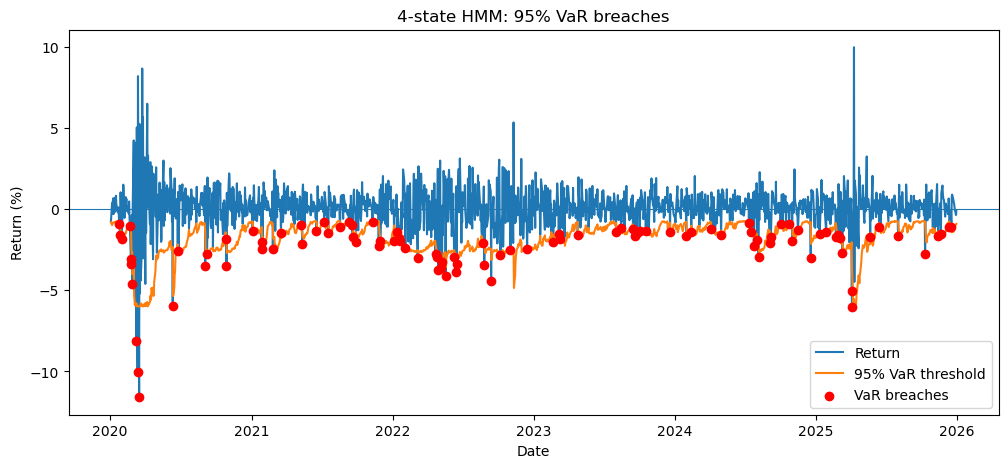

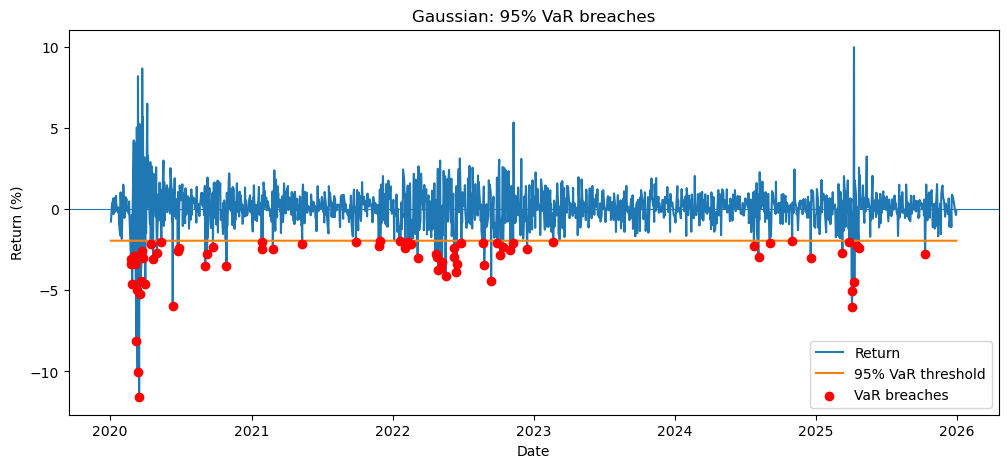

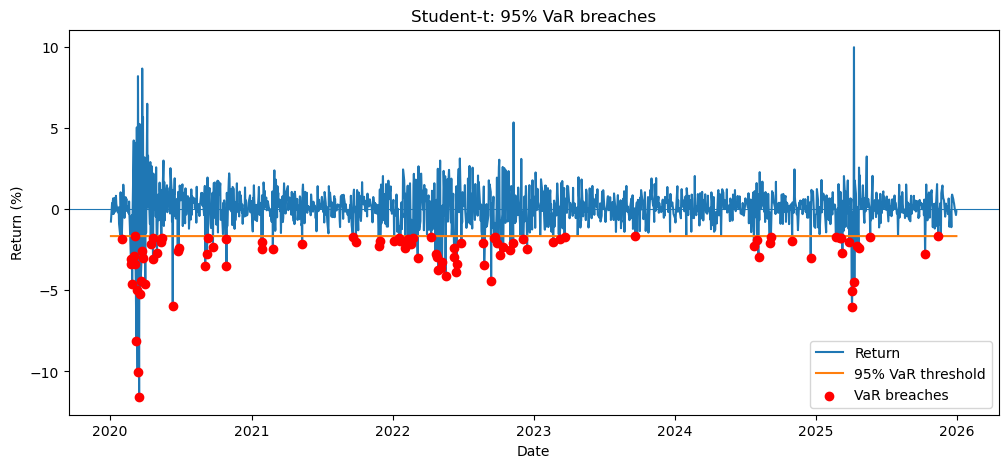

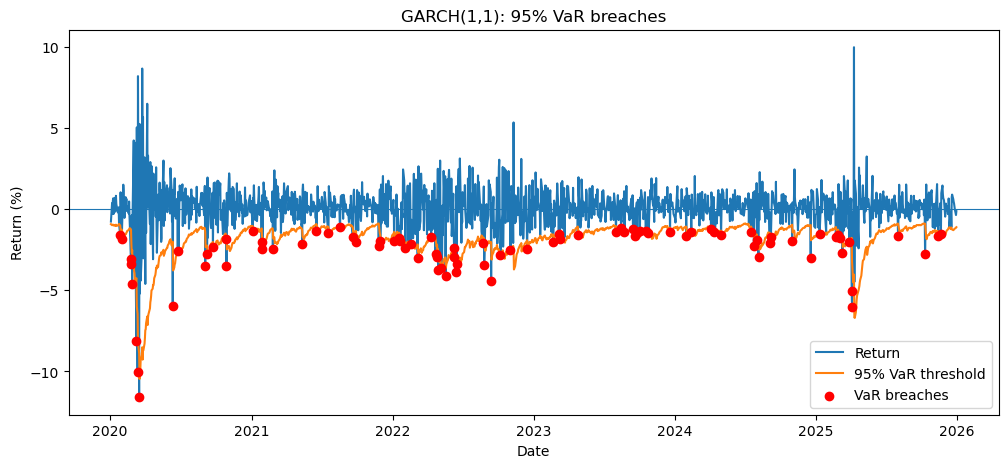

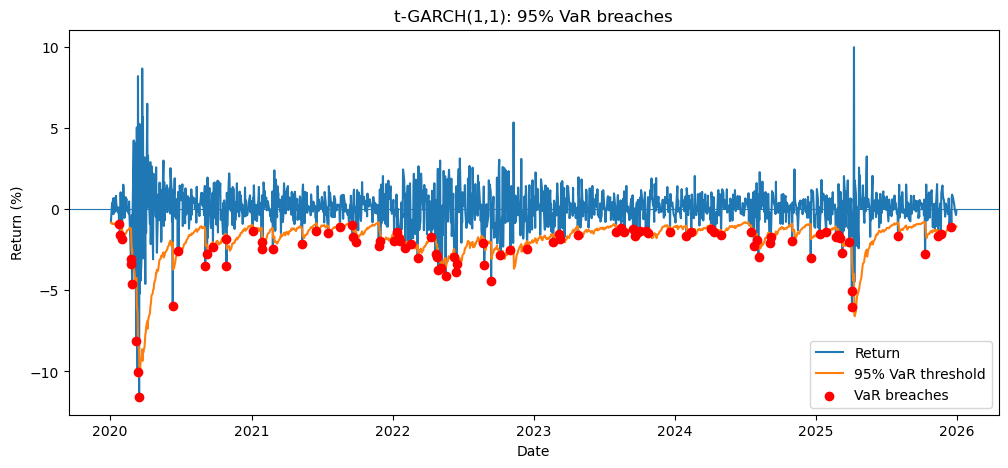

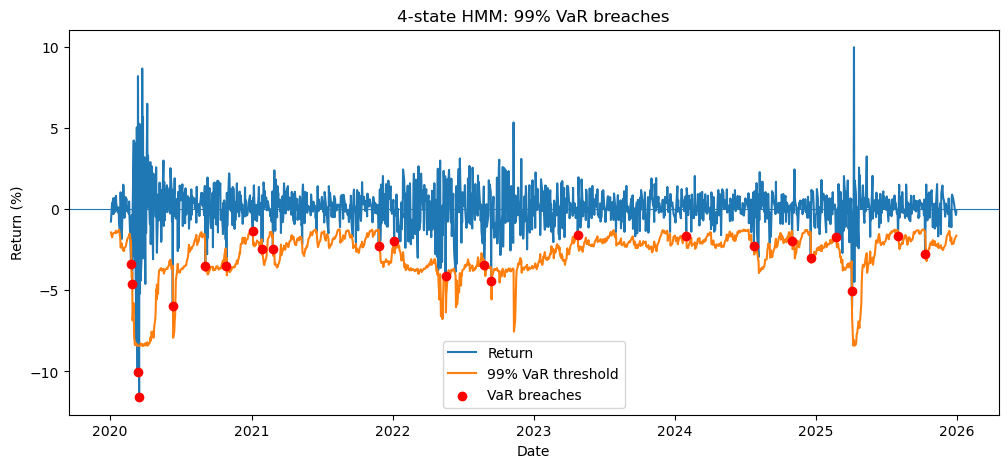

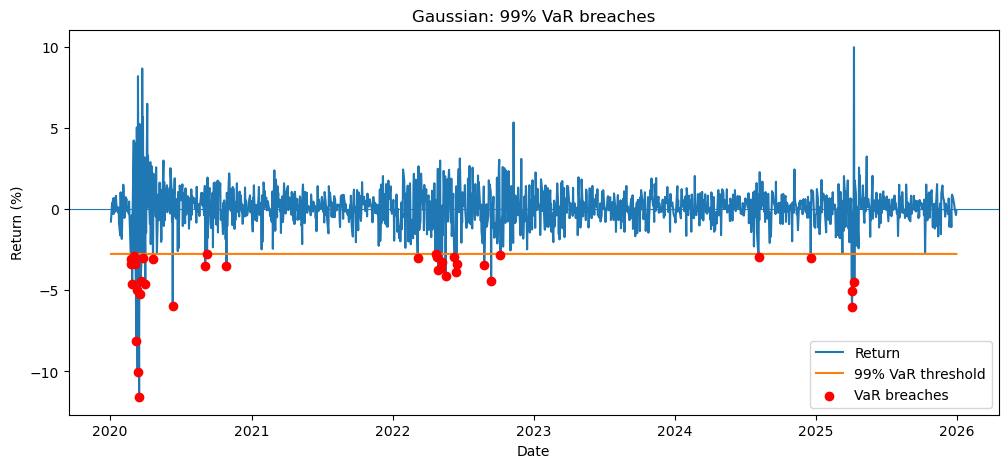

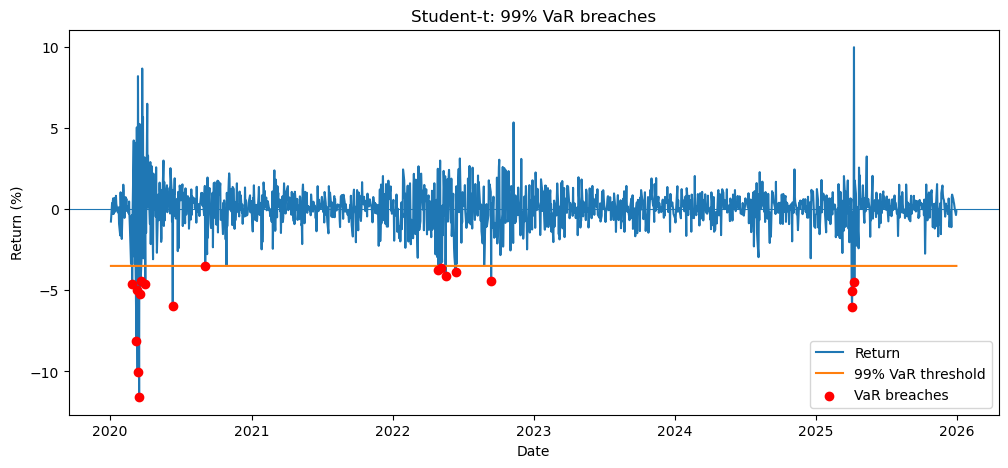

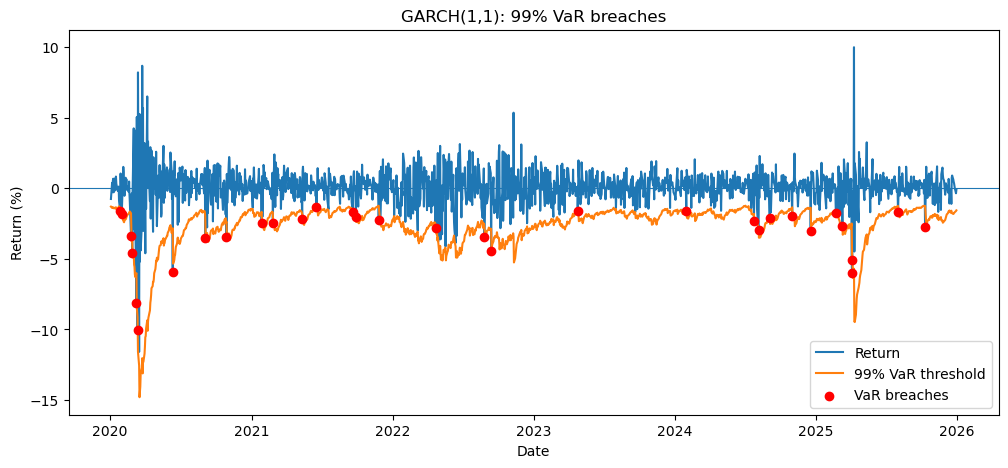

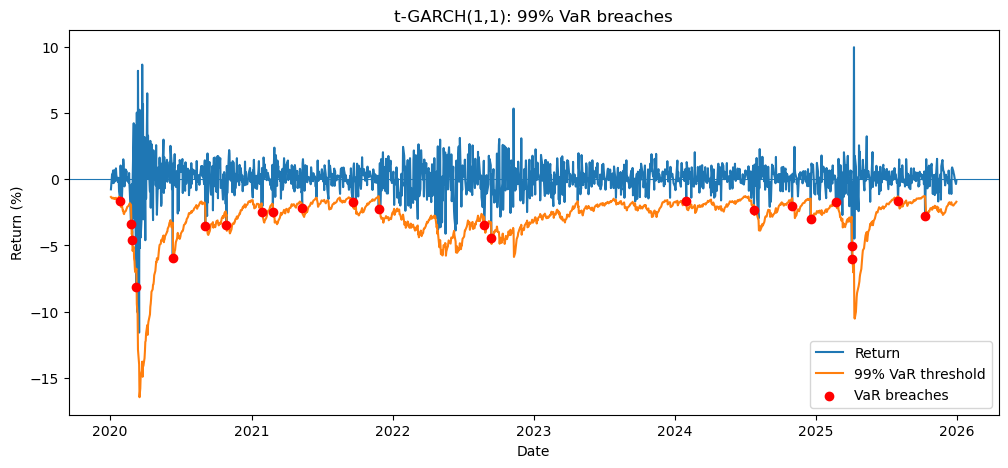

In [11]:
from src.plots.plot_breaches import plot_breaches

for i in range(2): 
    plot_breaches(
        VaR_results=VaR_results,
        breach_results=breach_results,
        logret_test=logret_test,
        model_names=list(all_models.keys()),
        level_idx=i
    )
    

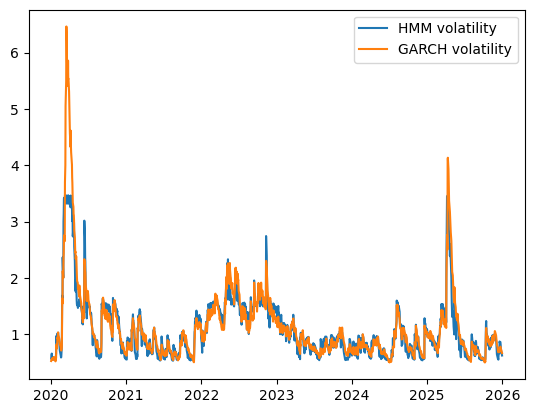

In [ ]:
dates = logret_test.index
hmm_vol = hmm4.volatility_forecast(logret_test)
garch_vol = garch_t.volatility_forecast(logret_test)

plt.plot(dates, hmm_vol, label="HMM volatility")
plt.plot(dates, garch_vol, label="GARCH volatility")
plt.legend()
plt.show()